# SIMPUL Tahap Tiga: Pemutakhiran Data Produksi dan Angka Final untuk Naskah

Tahap pertama menyusun kerangka analisis, tahap kedua mengganti asumsi dengan angka resmi.
Tahap ketiga menutup keterbatasan terakhir yang masih tersisa, yaitu umur data produksi
perikanan.

Kedua tahap sebelumnya memakai data produksi perikanan menurut kabupaten tahun 2018 karena
itulah satu satunya tahun yang lengkap pada berkas yang tersedia. Data tersebut berumur
delapan tahun dan banyak selnya kosong, sehingga hanya layak dipakai sebagai pola sebaran.
Penelusuran menemukan data yang jauh lebih baru pada portal Satu Data Provinsi Sulawesi
Tenggara, bersumber dari Dinas Kelautan dan Perikanan, untuk tahun 2024 dan lengkap pada
seluruh tujuh belas kabupaten dan kota.

Notebook ini menarik data tersebut langsung dari antarmuka pemrograman resmi provinsi,
menghitung ulang lapis ketiga, lalu membandingkan hasilnya dengan hasil yang memakai data
lama. Perbandingan itu adalah uji ketahanan yang sesungguhnya, karena menguji apakah
kesimpulan bergantung pada pilihan sumber data.

Keluaran akhir notebook ini adalah lembar angka final yang siap dipakai menyusun naskah.


## Catatan koreksi 23 September 2026

Fungsi `samakan()` pada Langkah pemuatan data KKP diperbaiki. Pada versi sebelumnya, nama Kota Baubau pada berkas KKP tidak terbakukan sehingga produksinya (18.705,5 ton) tercatat nol pada tabel sebaran ruang dan pemrograman linear. Setelah perbaikan, kebutuhan ikan program menjadi 1,91 persen produksi (sebelumnya 2,05 persen), seluruh kebutuhan terpenuhi dari dalam provinsi mulai batas serapan 2,0 persen (sebelumnya 2,5 persen), perpindahan antarkabupaten pada titik tersebut 1.547 ton atau 29,8 persen pasokan setempat (sebelumnya 1.595 ton atau 30,7 persen), dan indeks ketidaksesuaian ruang 0,3125 (sebelumnya 0,3503). Nilai yang sampai ke produsen tetap Rp136,3 miliar.

**Keluaran pada berkas ini masih keluaran lama.** Jalankan ulang seluruh sel di Google Colab (menu Runtime, Run all) sebelum mengunggah berkas ini ke GitHub agar keluarannya memuat angka terkoreksi. Versi notebook dan keluaran yang dipakai untuk naskah awal tetap tersimpan pada rilis `naskah-forkestra-2026`.


## Langkah 0. Lingkungan kerja dan hasil tahap sebelumnya

In [1]:
import subprocess, sys
subprocess.run([sys.executable, "-m", "pip", "install", "-q", "requests"], check=False)
subprocess.run(["apt-get", "-qq", "install", "-y", "fonts-liberation"],
               check=False, stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL)
print("Pemasangan pustaka selesai.")

Pemasangan pustaka selesai.


In [2]:
import os, re, glob, json, zipfile, shutil, warnings, datetime as dt
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
from matplotlib import font_manager

warnings.filterwarnings("ignore")
pd.set_option("display.width", 200); pd.set_option("display.max_columns", 40)

font_manager._load_fontmanager(try_read_cache=False)
_ada = {f.name for f in font_manager.fontManager.ttflist}
_urut = ["Times New Roman", "Liberation Serif", "Nimbus Roman", "DejaVu Serif"]
FONT = next((f for f in _urut if f in _ada), "serif")
matplotlib.rcParams.update({
    "font.family": "serif", "font.serif": [FONT] + _urut, "font.size": 13,
    "axes.titlesize": 13, "axes.labelsize": 13, "xtick.labelsize": 13,
    "ytick.labelsize": 13, "legend.fontsize": 13, "figure.titlesize": 13,
    "axes.unicode_minus": False, "figure.dpi": 110, "savefig.dpi": 300,
    "savefig.bbox": "tight", "savefig.pad_inches": 0.25, "axes.grid": True,
    "grid.alpha": 0.25, "grid.linewidth": 0.6, "axes.spines.top": False,
    "axes.spines.right": False, "legend.frameon": False})
WARNA = {"struktural": "#1f4e79", "koordinasi": "#c0504d", "campuran": "#7f7f7f",
         "aksen": "#2e7d32", "netral": "#404040", "muda": "#a6bddb", "sorot": "#b8860b"}
print("Huruf visualisasi:", FONT)

def siapkan():
    try:
        from google.colab import drive
        drive.mount("/content/drive", force_remount=False)
        akar = "/content/drive/MyDrive/SIMPUL_Forkestra2026_Tahap3"; colab = True
    except Exception:
        akar = os.path.abspath("./SIMPUL_Forkestra2026_Tahap3"); colab = False
    j = {"akar": akar}
    for s in ["01_masukan", "02_tabel", "03_gambar", "04_final"]:
        p = os.path.join(akar, s); os.makedirs(p, exist_ok=True); j[s] = p
    return j, colab

JALUR, DI_COLAB = siapkan()
print("Berjalan di Colab:", DI_COLAB, "| akar:", JALUR["akar"])

def cari(pola):
    lokasi = [JALUR["01_masukan"], "/content", os.getcwd(), "/mnt/user-data/uploads",
              "/content/drive/MyDrive/SIMPUL_Forkestra2026",
              "/content/drive/MyDrive/SIMPUL_Forkestra2026_Tahap2",
              os.path.abspath("./SIMPUL_Forkestra2026"),
              os.path.abspath("./SIMPUL_Forkestra2026_Tahap2")]
    hit = []
    for d in lokasi:
        if os.path.isdir(d):
            hit += glob.glob(os.path.join(d, pola))
    return sorted(hit, key=os.path.getmtime)[-1] if hit else None

ARSIP1 = cari("SIMPUL_Forkestra2026_hasil_*.zip")
ARSIP2 = cari("SIMPUL_Forkestra2026_tahap2_*.zip")

if (ARSIP1 is None or ARSIP2 is None) and DI_COLAB:
    print("Arsip tahap sebelumnya belum lengkap. Silakan unggah kedua berkas zip.")
    from google.colab import files
    for nama in files.upload():
        shutil.move(nama, os.path.join(JALUR["01_masukan"], nama))
    ARSIP1 = cari("SIMPUL_Forkestra2026_hasil_*.zip")
    ARSIP2 = cari("SIMPUL_Forkestra2026_tahap2_*.zip")

EKS = os.path.join(JALUR["01_masukan"], "sebelumnya"); os.makedirs(EKS, exist_ok=True)
for a in [ARSIP1, ARSIP2]:
    if a:
        with zipfile.ZipFile(a) as z:
            z.extractall(EKS)
        print("Termuat:", os.path.basename(a))

def berkas(pola):
    h = glob.glob(os.path.join(EKS, "**", pola), recursive=True)
    return h[0] if h else None

SEB = {}
for nama, pola in [("perikanan18", "bersih_perikanan.csv"),
                   ("penduduk", "bersih_penduduk.csv"),
                   ("tongkol", "bersih_tongkol.csv"),
                   ("biaya_friksi", "table2_friction_cost.csv"),
                   ("parameter", "table9_parameter_provenance.csv"),
                   ("taksonomi", "table1_friction_taxonomy.csv"),
                   ("tangga_nilai", "table6_fishery_value_ladder.csv")]:
    p = berkas(pola)
    SEB[nama] = pd.read_csv(p) if p else None
    print("  %-14s %s" % (nama, "ada" if p else "TIDAK ADA"))

p2 = berkas("catatan_teknis_tahap2.json")
CT2 = json.load(open(p2, encoding="utf-8")) if p2 else {}
P = dict(CT2.get("parameter_resmi", {}))
P.update(CT2.get("parameter_turunan", {}))
P.update(CT2.get("asumsi_tersisa", {}))
print("\nParameter tahap dua termuat:", len(P), "butir")

Huruf visualisasi: Liberation Serif
Mounted at /content/drive
Berjalan di Colab: True | akar: /content/drive/MyDrive/SIMPUL_Forkestra2026_Tahap3
Arsip tahap sebelumnya belum lengkap. Silakan unggah kedua berkas zip.


Saving SIMPUL_Forkestra2026_tahap2_20260821_1646.zip to SIMPUL_Forkestra2026_tahap2_20260821_1646.zip
Saving SIMPUL_Forkestra2026_hasil_20260821_1623.zip to SIMPUL_Forkestra2026_hasil_20260821_1623.zip
Termuat: SIMPUL_Forkestra2026_hasil_20260821_1623.zip
Termuat: SIMPUL_Forkestra2026_tahap2_20260821_1646.zip
  perikanan18    ada
  penduduk       ada
  tongkol        ada
  biaya_friksi   ada
  parameter      ada
  taksonomi      ada
  tangga_nilai   ada

Parameter tahap dua termuat: 19 butir


## Langkah 1. Memuat data perikanan dari dua sumber resmi

Dua sumber dipakai. Yang pertama adalah portal data Kementerian Kelautan dan Perikanan,
yang menyediakan produksi perikanan tangkap tahun 2024 sampai tingkat jenis ikan pada
setiap kabupaten, lengkap dengan volume, nilai, dan harga rata rata tertimbang yang
diterima produsen. Yang kedua adalah portal Satu Data Provinsi Sulawesi Tenggara yang
bersumber dari Dinas Kelautan dan Perikanan, memuat total produksi tangkap pada setiap
kabupaten untuk tahun yang sama.

Memakai dua sumber yang disusun lembaga berbeda memungkinkan pemeriksaan silang. Apabila
totalnya berdekatan, keduanya saling menguatkan dan angka yang dipakai menjadi jauh lebih
dapat dipertanggungjawabkan daripada bila hanya bersandar pada satu sumber.

Sumber pertama membawa sesuatu yang belum pernah tersedia pada tahap sebelumnya, yaitu
harga yang benar benar diterima nelayan, terpisah menurut kabupaten dan jenis ikan. Data
inilah yang memungkinkan lapis pertama diperluas dari harga eceran ke harga produsen.


In [3]:
def samakan(s):
    """Menyeragamkan penulisan nama kabupaten dan kota dari berbagai sumber.

    Koreksi 23 September 2026: huruf diseragamkan lebih dahulu, baru kemudian nama
    Baubau dibakukan. Pada versi sebelumnya penggantian "Bau Bau" dilakukan sebelum
    penyeragaman huruf, sehingga nama "BAU BAU" dari berkas KKP tidak terganti dan
    produksi Kota Baubau (18.705,5 ton) tidak terbaca pada tabel sebaran ruang.
    """
    s = str(s).strip()
    s = re.sub(r"^(Kota|Kabupaten|Kab\.?)\s+", "", s, flags=re.IGNORECASE).strip().title()
    s = re.sub(r"^Bau[\s-]*Bau$", "Baubau", s, flags=re.IGNORECASE)
    s = s.replace("Konawe Kep.", "Konawe Kepulauan")
    return s.strip()

def cari_kkp():
    pola = ["produksi_perikanan*.xlsx", "*perikanan*.xlsx"]
    lokasi = [JALUR["01_masukan"], "/content", os.getcwd(), "/mnt/user-data/uploads",
              "/content/drive/MyDrive"]
    for d in lokasi:
        if not os.path.isdir(d):
            continue
        for p in pola:
            hit = glob.glob(os.path.join(d, p))
            if hit:
                return sorted(hit, key=os.path.getmtime)[-1]
    return None

BERKAS_KKP = cari_kkp()
if BERKAS_KKP is None and DI_COLAB:
    print("Berkas produksi perikanan dari portal KKP belum ditemukan.")
    print("Silakan unggah berkas produksi_perikanan.xlsx.")
    from google.colab import files
    for nama in files.upload():
        shutil.move(nama, os.path.join(JALUR["01_masukan"], nama))
    BERKAS_KKP = cari_kkp()
if BERKAS_KKP is None:
    raise FileNotFoundError("Berkas produksi perikanan KKP tidak ditemukan.")

def baca_kkp(path):
    """Berkas portal KKP memuat dua baris keterangan sumber sebelum kepala tabel."""
    from openpyxl import load_workbook
    wb = load_workbook(path, read_only=True, data_only=True)
    baris = list(wb[wb.sheetnames[0]].iter_rows(values_only=True))
    wb.close()
    keterangan = [str(v) for r in baris[:3] for v in r if v]
    kepala = next(i for i, r in enumerate(baris)
                  if r and any(str(v).strip() == "Tahun" for v in r if v))
    kolom = [str(c).strip() if c is not None else "kosong" for c in baris[kepala]]
    d = pd.DataFrame(baris[kepala + 1:], columns=kolom)
    d = d.drop(columns=[c for c in d.columns if c == "kosong"], errors="ignore")
    d = d.dropna(subset=["Tahun"])
    d = d.rename(columns={"Kab / Kota": "kabkota", "Kelompok Ikan": "kelompok",
                          "Jenis Ikan": "jenis", "Jenis Usaha": "usaha",
                          "Volume (ton)": "ton", "Nilai (Rp. Juta)": "nilai_juta",
                          "Harga Rata-Rata Tertimbang (Rp/kg)": "harga_kg"})
    for c in ["ton", "nilai_juta", "harga_kg"]:
        d[c] = pd.to_numeric(d[c], errors="coerce")
    d["wilayah"] = d.kabkota.map(samakan)
    return d, keterangan

KKP, KET_KKP = baca_kkp(BERKAS_KKP)
print("Berkas KKP:", os.path.basename(BERKAS_KKP))
for k in KET_KKP:
    print("  ", k)
print()
print("Baris          :", len(KKP))
print("Tahun          :", sorted(KKP.Tahun.unique()))
print("Kabupaten kota :", KKP.wilayah.nunique())
print("Kelompok ikan  :", KKP.kelompok.nunique(), "| jenis ikan:", KKP.jenis.nunique())
print("Jenis usaha    :", KKP.usaha.value_counts().to_dict())
print("Total volume   : %s ton" % format(KKP.ton.sum(), ",.1f"))
print("Total nilai    : Rp%s miliar" % format(KKP.nilai_juta.sum() / 1000, ",.1f"))

TAHUN_PRODUKSI = int(KKP.Tahun.max())
LAUT = KKP[KKP.usaha == "LAUT"].copy()
NILAI_PRODUKSI = float(KKP.nilai_juta.sum() * 1e6)
KKP.to_csv(os.path.join(JALUR["02_tabel"], "table18_kkp_detail.csv"), index=False)

Berkas produksi perikanan dari portal KKP belum ditemukan.
Silakan unggah berkas produksi_perikanan.xlsx.


Saving produksi perikanan.xlsx to produksi perikanan.xlsx
Berkas KKP: produksi perikanan.xlsx
   Sumber: https://portaldata.kkp.go.id
   Produksi Perikanan Tangkap
   Waktu Unduh : 21 Agustus 2026, 23:52:25

Baris          : 747
Tahun          : [np.int64(2024)]
Kabupaten kota : 17
Kelompok ikan  : 78 | jenis ikan: 247
Jenis usaha    : {'LAUT': 705, 'PERAIRAN DARAT': 42}
Total volume   : 272,456.7 ton
Total nilai    : Rp7,155.0 miliar


In [4]:
# --- sumber kedua: portal Satu Data Provinsi Sulawesi Tenggara ---
KODE_TABEL = "tabel_74_356"
POLA_API = "https://simdata.sultraprov.go.id/api/fetch-data/{kode}/{tahun}"
HALAMAN = "https://simdata.sultraprov.go.id/detail-tabel/{kode}/{tahun}"

# Salinan tercatat hasil penarikan pada 21 Agustus 2026. Nilai pemutakhiran yang
# tercantum pada portal adalah 14 Juli 2025.
SALINAN = {"Bombana": 29473, "Buton": 19317, "Buton Selatan": 24189,
           "Buton Tengah": 25854, "Buton Utara": 8825, "Kolaka": 22362,
           "Kolaka Timur": 177, "Kolaka Utara": 7053, "Konawe": 3641,
           "Konawe Kepulauan": 9562, "Konawe Selatan": 10692, "Konawe Utara": 15463,
           "Muna": 18930, "Muna Barat": 14398, "Wakatobi": 22391, "Bau Bau": 18706,
           "Kendari": 20213}

def tarik_satu_data(tahun, jeda=12):
    import requests
    r = requests.get(POLA_API.format(kode=KODE_TABEL, tahun=tahun), timeout=jeda)
    r.raise_for_status()
    j = r.json()
    if int(j.get("status", 0)) != 200 or not j.get("data"):
        raise ValueError("data kosong")
    baris = []
    for d in j["data"]:
        kunci = sorted(k for k in d if k.startswith(KODE_TABEL))
        baris.append((samakan(d[kunci[0]]), float(str(d[kunci[1]]).replace(",", ""))))
    return pd.Series(dict(baris)), j["data"][0].get("updated_at", "tidak tercantum")

try:
    DKP, PEMUTAKHIRAN = tarik_satu_data(TAHUN_PRODUKSI)
    ASAL_DKP = "Antarmuka pemrograman Satu Data Provinsi Sulawesi Tenggara"
    print("Penarikan dari portal provinsi berhasil, %d wilayah." % len(DKP))
except Exception as e:
    DKP = pd.Series({samakan(k): float(v) for k, v in SALINAN.items()})
    PEMUTAKHIRAN = "2025-07-14"
    ASAL_DKP = "Salinan tercatat hasil penarikan 21 Agustus 2026"
    print("Penarikan langsung tidak berhasil (%s), beralih ke salinan tercatat."
          % type(e).__name__)

print("Sumber        :", ASAL_DKP)
print("Alamat        :", HALAMAN.format(kode=KODE_TABEL, tahun=TAHUN_PRODUKSI))
print("Pemutakhiran  :", PEMUTAKHIRAN)
print()

# --- pemeriksaan silang antarsumber ---
kkp_kab = LAUT.groupby("wilayah").ton.sum()
kkp_semua = KKP.groupby("wilayah").ton.sum()
SILANG = pd.DataFrame({"KKP all capture (t)": kkp_semua,
                       "KKP marine only (t)": kkp_kab,
                       "Provincial portal (t)": DKP}).dropna(how="all")
SILANG["Difference (t)"] = SILANG["KKP all capture (t)"] - SILANG["Provincial portal (t)"]
SILANG["Difference (%)"] = (SILANG["Difference (t)"] /
                            SILANG["Provincial portal (t)"].replace(0, np.nan) * 100)
SILANG.index.name = "District"
print(SILANG.round(1).to_string())

tot_kkp, tot_dkp = SILANG["KKP all capture (t)"].sum(), SILANG["Provincial portal (t)"].sum()
SELISIH_SUMBER = abs(tot_kkp - tot_dkp) / tot_dkp * 100
print()
print("Total menurut KKP            : %s ton" % format(tot_kkp, ",.0f"))
print("Total menurut portal provinsi: %s ton" % format(tot_dkp, ",.0f"))
print("Selisih antarsumber          : %.2f persen" % SELISIH_SUMBER)
if SELISIH_SUMBER < 2:
    print("Kedua sumber saling menguatkan, sehingga angka produksi dapat dipakai "
          "dengan keyakinan tinggi.")
else:
    print("Terdapat selisih yang perlu ditelusuri sebelum angka dipakai.")
SILANG.round(2).to_csv(os.path.join(JALUR["02_tabel"],
                       "table19_source_crosscheck.csv"))

Penarikan langsung tidak berhasil (HTTPError), beralih ke salinan tercatat.
Sumber        : Salinan tercatat hasil penarikan 21 Agustus 2026
Alamat        : https://simdata.sultraprov.go.id/detail-tabel/tabel_74_356/2024
Pemutakhiran  : 2025-07-14

                  KKP all capture (t)  KKP marine only (t)  Provincial portal (t)  Difference (t)  Difference (%)
District                                                                                                         
Baubau                        18705.5              18705.5                18706.0            -0.5            -0.0
Bombana                       29516.0              29516.0                29473.0            43.0             0.1
Buton                         19333.4              19333.4                19317.0            16.4             0.1
Buton Selatan                 24188.6              24188.6                24189.0            -0.4            -0.0
Buton Tengah                  25854.7              25854.7         

## Langkah 2. Memperluas lapis pertama ke harga produsen

Lapis pertama pada tahap satu mengukur selisih harga eceran antara dua kota. Ukuran itu
menjelaskan apa yang dihadapi konsumen, tetapi tidak menjelaskan apa yang dihadapi nelayan.
Data harga rata rata tertimbang dari portal KKP kini memungkinkan pengukuran yang sama
dilakukan pada tingkat produsen, di seluruh tujuh belas kabupaten, dan terpisah menurut
jenis ikan.

Ukuran yang dipakai adalah simpangan baku logaritma harga antarkabupaten untuk satu jenis
ikan yang sama, ditambah rasio harga tertinggi terhadap harga terendah. Perhitungan
dibatasi pada jenis ikan yang tercatat di sekurangnya delapan kabupaten dengan volume
sekurangnya lima puluh ton, agar harga yang dibandingkan berasal dari pasar yang benar
benar berjalan dan bukan dari catatan yang sangat tipis.

$$\sigma_j = \text{sd}\left( \ln P_{jk} \right), \qquad
R_j = \frac{\max_k P_{jk}}{\min_k P_{jk}}$$

dengan $P_{jk}$ adalah harga rata rata tertimbang jenis ikan $j$ pada kabupaten $k$.
Perbandingan langsung terhadap hasil lapis pertama menjawab pertanyaan pokok, yaitu apakah
sebaran harga yang dihadapi nelayan lebih lebar atau lebih sempit daripada sebaran yang
dihadapi konsumen.


In [5]:
MIN_KAB, MIN_TON = 8, 50.0

def harga_per_wilayah(d):
    """Harga rata rata tertimbang volume pada tiap wilayah."""
    return d.groupby("wilayah").apply(
        lambda x: np.average(x.harga_kg, weights=x.ton) if x.ton.sum() > 0 else np.nan,
        include_groups=False).dropna()

baris, simpanan = [], {}
for jenis, sub in LAUT.groupby("jenis"):
    s = sub[sub.ton >= MIN_TON]
    if s.wilayah.nunique() < MIN_KAB:
        continue
    h = harga_per_wilayah(s)
    if len(h) < MIN_KAB or h.min() <= 0:
        continue
    simpanan[jenis] = h
    baris.append(dict(Species=jenis, Districts=len(h), Volume_t=float(s.ton.sum()),
                      Min_IDR=float(h.min()), Median_IDR=float(h.median()),
                      Max_IDR=float(h.max()), Ratio=float(h.max() / h.min()),
                      SD_log=float(np.log(h).std())))

DISPERSI = pd.DataFrame(baris).sort_values("Volume_t", ascending=False)
print("Sebaran harga produsen antarkabupaten menurut jenis ikan, tahun %d"
      % TAHUN_PRODUKSI)
print(DISPERSI.round(3).to_string(index=False))
DISPERSI.round(3).to_csv(os.path.join(JALUR["02_tabel"],
                         "table20_producer_price_dispersion.csv"), index=False)

SD_PRODUSEN = float(DISPERSI.SD_log.mean())
RASIO_PRODUSEN = float(DISPERSI.Ratio.mean())
print()
print("Rata rata rasio harga tertinggi terhadap terendah : %.2f kali" % RASIO_PRODUSEN)
print("Rata rata simpangan baku logaritma harga          : %.3f" % SD_PRODUSEN)

Sebaran harga produsen antarkabupaten menurut jenis ikan, tahun 2024
              Species  Districts  Volume_t  Min_IDR  Median_IDR  Max_IDR  Ratio  SD_log
             CAKALANG         12  19908.23  15000.0     20105.0  35000.0  2.333   0.260
    TUNA SIRIP KUNING         12  12215.26  15000.0     26837.5  50000.0  3.333   0.367
       KEMBUNG LELAKI          9   9444.52  20000.0     28968.0  39639.0  1.982   0.216
       KEMBUNG GEPENG         11   9212.00  17263.0     25000.0  40000.0  2.317   0.267
                 KUWE         11   8363.60  20000.0     35000.0  50000.0  2.500   0.302
 TEMBANG GARIS KUNING         14   7639.63   8820.0     12040.0  25000.0  2.834   0.297
               LENCAM          9   7306.38  20000.0     30000.0  40000.0  2.000   0.194
             TENGGIRI         14   5915.32  20000.0     40000.0  78000.0  3.900   0.357
            CUMI-CUMI         14   5230.84  20000.0     32794.0  50000.0  2.500   0.258
       LAYANG BENGGOL          9   4497.38   8480.0

### Menguji apakah sebaran itu hanya akibat pembulatan pelaporan

Sebagian besar harga pada berkas sumber tercatat dalam angka bulat, yang menandakan
pelaporan lapangan dilakukan secara kasar. Pembulatan semacam itu menambah derau, dan derau
akan memperbesar ukuran sebaran meskipun harga sebenarnya seragam. Karena itu perlu diuji
apakah sebaran yang teramati dapat dihasilkan oleh pembulatan semata.

Pengujian dilakukan dengan simulasi. Setiap jenis ikan diandaikan memiliki satu harga
sejati yang berlaku sama di seluruh kabupaten. Harga itu diganggu sedikit, lalu dibulatkan
sebagaimana pelapor lapangan membulatkan, dan sebaran yang dihasilkan dihitung. Prosedur
ini diulang ribuan kali sehingga diperoleh sebaran peluang dari ukuran sebaran di bawah
anggapan bahwa harga sebenarnya seragam.

Apabila sebaran yang teramati jauh melampaui apa yang dapat dihasilkan simulasi, maka
sebaran itu tidak dapat dijelaskan oleh pembulatan dan harus berasal dari perbedaan harga
yang sesungguhnya.


In [6]:
kelipatan_5000 = float((LAUT.harga_kg % 5000 == 0).mean())
kelipatan_1000 = float((LAUT.harga_kg % 1000 == 0).mean())
print("Harga yang merupakan kelipatan Rp5.000 : %.1f persen" % (kelipatan_5000 * 100))
print("Harga yang merupakan kelipatan Rp1.000 : %.1f persen" % (kelipatan_1000 * 100))
print()

struktur = [(float(np.average(LAUT[(LAUT.jenis == j) & (LAUT.ton >= MIN_TON)].harga_kg,
                              weights=LAUT[(LAUT.jenis == j) &
                                           (LAUT.ton >= MIN_TON)].ton)), len(h))
            for j, h in simpanan.items()]

def simulasi_pembulatan(kelipatan, n_ulang=3000, benih=2026):
    acak = np.random.default_rng(benih)
    keluar = np.empty(n_ulang)
    for i in range(n_ulang):
        sd = []
        for harga_sejati, k in struktur:
            kasar = np.round(harga_sejati * (1 + acak.normal(0, 0.02, k)) / kelipatan) * kelipatan
            sd.append(np.log(np.clip(kasar, kelipatan, None)).std())
        keluar[i] = np.mean(sd)
    return keluar

UJI_BULAT = []
for kel in [1000, 5000]:
    sim = simulasi_pembulatan(kel)
    UJI_BULAT.append(dict(Rounding_IDR=kel, Simulated_mean=float(sim.mean()),
                          Simulated_p99=float(np.percentile(sim, 99)),
                          Observed=SD_PRODUSEN,
                          Ratio=SD_PRODUSEN / float(sim.mean()),
                          p_value=float((sim >= SD_PRODUSEN).mean())))
UJI = pd.DataFrame(UJI_BULAT)
print(UJI.round(4).to_string(index=False))
UJI.round(4).to_csv(os.path.join(JALUR["02_tabel"],
                    "table21_rounding_test.csv"), index=False)

print()
if UJI.p_value.max() < 0.01:
    print("Sebaran yang teramati %.1f kali lebih besar daripada yang dapat dihasilkan "
          "pembulatan, dengan peluang kurang dari satu persen." % UJI.Ratio.min())
    print("Pembulatan pelaporan menambah derau tetapi tidak menjelaskan sebaran harga "
          "produsen. Sebaran itu nyata.")
else:
    print("Pembulatan pelaporan dapat menjelaskan sebagian besar sebaran yang teramati, "
          "sehingga temuan ini tidak dapat dipertahankan.")

Harga yang merupakan kelipatan Rp5.000 : 68.5 persen
Harga yang merupakan kelipatan Rp1.000 : 73.6 persen

 Rounding_IDR  Simulated_mean  Simulated_p99  Observed   Ratio  p_value
         1000          0.0206         0.0243    0.2977 14.4640      0.0
         5000          0.0209         0.0333    0.2977 14.2444      0.0

Sebaran yang teramati 14.2 kali lebih besar daripada yang dapat dihasilkan pembulatan, dengan peluang kurang dari satu persen.
Pembulatan pelaporan menambah derau tetapi tidak menjelaskan sebaran harga produsen. Sebaran itu nyata.


### Membandingkan sebaran di tingkat produsen dan di tingkat eceran

Perbandingan ini adalah inti temuan tahap ketiga. Ukuran yang sama, yaitu simpangan baku
logaritma harga, dihitung pada dua tingkat pasar yang berbeda. Pada tingkat eceran ukuran
itu diambil dari selisih harga antara dua kota hasil lapis pertama, sedangkan pada tingkat
produsen diambil dari sebaran harga antarkabupaten.

Perlu dicatat bahwa keduanya tidak sepenuhnya setara. Ukuran eceran berasal dari dua kota
dan sepuluh komoditas pangan, sedangkan ukuran produsen berasal dari belasan kabupaten dan
belasan jenis ikan. Ketaksetaraan ini disebutkan terbuka. Meskipun demikian, selisih
besarannya cukup lebar sehingga arah kesimpulan tidak berubah oleh perbedaan cakupan.


In [7]:
selisih = SEB.get("selisih_eceran")
if selisih is None:
    p = berkas("bersih_selisih.csv")
    selisih = pd.read_csv(p) if p else None

SD_ECERAN = float(selisih.groupby("komoditas").selisih_log.std().mean())
LIPAT = SD_PRODUSEN / SD_ECERAN

TINGKAT = pd.DataFrame([
    dict(Market_level="Retail, between two cities",
         SD_log=SD_ECERAN, Coverage="10 staple foods, 2 cities, 2020-2026"),
    dict(Market_level="Producer, between districts",
         SD_log=SD_PRODUSEN,
         Coverage="%d fish species, up to %d districts, %d"
                  % (len(DISPERSI), int(DISPERSI.Districts.max()), TAHUN_PRODUKSI)),
])
print(TINGKAT.round(4).to_string(index=False))
print()
print("Sebaran harga yang dihadapi nelayan %.1f kali lebih lebar daripada sebaran yang "
      "dihadapi konsumen." % LIPAT)
print()
print("Bacaannya sebagai berikut. Barang jadi bergerak antarkota sehingga harga eceran "
      "saling mendekat, sedangkan hasil tangkapan tidak bergerak antarkabupaten sehingga "
      "harga yang diterima nelayan tetap terpisah pisah. Persoalan integrasi pasar di "
      "Sulawesi Tenggara terletak di hulu, bukan di hilir.")
TINGKAT.round(4).to_csv(os.path.join(JALUR["02_tabel"],
                        "table22_market_level_comparison.csv"), index=False)

               Market_level  SD_log                                  Coverage
 Retail, between two cities  0.0989      10 staple foods, 2 cities, 2020-2026
Producer, between districts  0.2977 14 fish species, up to 14 districts, 2024

Sebaran harga yang dihadapi nelayan 3.0 kali lebih lebar daripada sebaran yang dihadapi konsumen.

Bacaannya sebagai berikut. Barang jadi bergerak antarkota sehingga harga eceran saling mendekat, sedangkan hasil tangkapan tidak bergerak antarkabupaten sehingga harga yang diterima nelayan tetap terpisah pisah. Persoalan integrasi pasar di Sulawesi Tenggara terletak di hulu, bukan di hilir.


### Menguji satu penjelasan tandingan

Penjelasan yang paling mudah diajukan untuk sebaran harga produsen adalah kekuatan tawar
pembeli. Menurut penjelasan itu, kabupaten dengan produksi besar menghadapi pembeli yang
lebih kuat sehingga harga yang diterima nelayan tertekan.

Pengujian dilakukan dengan tiga spesifikasi bertingkat. Spesifikasi pertama meregresikan
logaritma harga terhadap logaritma volume tanpa pengendali apa pun. Spesifikasi ini paling
lemah karena harga antarjenis ikan memang berbeda jauh, sehingga hubungan yang terlihat
dapat berasal dari perbedaan jenis dan bukan dari volume.

Spesifikasi kedua menambahkan efek tetap jenis ikan, sehingga perbandingan dilakukan
sepenuhnya di dalam jenis yang sama. Spesifikasi ketiga menambahkan pula efek tetap
kabupaten, sehingga perbedaan tingkat harga yang melekat pada suatu wilayah, misalnya
karena jaraknya ke pusat pengumpulan, ikut disingkirkan.

$$\ln P_{jk} = eta \ln Q_{jk} + lpha_j + \gamma_k + arepsilon_{jk}$$

Yang diperiksa bukan hanya apakah $eta$ berbeda dari nol, melainkan juga seberapa besar
bagian sebaran harga yang dapat dijelaskannya. Sebuah hubungan dapat nyata secara
statistik namun tetap kecil pengaruhnya, dan pembedaan itu menentukan kesimpulan
kebijakannya.


In [8]:
from scipy import stats

uji = []
for jenis, h in simpanan.items():
    s = LAUT[(LAUT.jenis == jenis) & (LAUT.ton >= MIN_TON)]
    v = s.groupby("wilayah").ton.sum().reindex(h.index)
    for w in h.index:
        uji.append(dict(species=jenis, district=w, price=h[w], volume=v[w]))
UJI_TAWAR = pd.DataFrame(uji).dropna()
UJI_TAWAR["ln_price"] = np.log(UJI_TAWAR.price)
UJI_TAWAR["ln_volume"] = np.log(UJI_TAWAR.volume)

def buang_rata(d, kolom, kelompok):
    """Menyingkirkan rata rata kelompok, setara dengan efek tetap."""
    return d[kolom] - d.groupby(kelompok)[kolom].transform("mean")

def regresi(x, y, k_parameter):
    r = stats.linregress(x, y)
    dof = max(len(x) - k_parameter, 1)
    t = r.slope / r.stderr if r.stderr > 0 else np.nan
    p = 2 * (1 - stats.t.cdf(abs(t), dof)) if np.isfinite(t) else np.nan
    return r.slope, r.stderr, p, r.rvalue ** 2, dof

spesifikasi = []

b, se, p, r2, dof = regresi(UJI_TAWAR.ln_volume, UJI_TAWAR.ln_price, 2)
spesifikasi.append(dict(Specification="Pooled, no fixed effects", Slope=b, SE=se,
                        p_value=p, R2=r2, df=dof))

d1 = UJI_TAWAR.copy()
d1["y"] = buang_rata(d1, "ln_price", "species")
d1["x"] = buang_rata(d1, "ln_volume", "species")
b, se, p, r2, dof = regresi(d1.x, d1.y, d1.species.nunique() + 1)
spesifikasi.append(dict(Specification="Species fixed effects", Slope=b, SE=se,
                        p_value=p, R2=r2, df=dof))
R2_DALAM = r2

d2 = UJI_TAWAR.copy()
for _ in range(80):        # penyingkiran dua arah secara berulang
    for kolom in ["ln_price", "ln_volume"]:
        d2[kolom] = (d2[kolom] - d2.groupby("species")[kolom].transform("mean")
                     - d2.groupby("district")[kolom].transform("mean")
                     + d2[kolom].mean())
b, se, p, r2, dof = regresi(d2.ln_volume, d2.ln_price,
                            UJI_TAWAR.species.nunique() + UJI_TAWAR.district.nunique())
spesifikasi.append(dict(Specification="Species and district fixed effects", Slope=b,
                        SE=se, p_value=p, R2=r2, df=dof))

TAWAR = pd.DataFrame(spesifikasi)
print("Regresi logaritma harga terhadap logaritma volume, n = %d" % len(UJI_TAWAR))
print(TAWAR.round(4).to_string(index=False))
TAWAR.round(4).to_csv(os.path.join(JALUR["02_tabel"],
                      "table23_bargaining_test.csv"), index=False)

ELASTISITAS = float(TAWAR.Slope.iloc[1])
P_TAWAR = float(TAWAR.p_value.iloc[1])
efek_ganda = float(TAWAR.Slope.abs().max()) * np.log(2) * 100
print()
if P_TAWAR < 0.05 and ELASTISITAS < 0:
    VONIS_TAWAR = "nyata namun kecil"
    print("Hubungan bertanda negatif dan nyata pada ketiga spesifikasi, sehingga "
          "kekuatan tawar pembeli memang bekerja.")
    print("Namun besarnya kecil. Penggandaan volume tangkapan hanya menurunkan harga "
          "produsen sekitar %.1f persen." % efek_ganda)
    print("Daya jelasnya juga rendah, yaitu %.1f persen ragam harga di dalam jenis ikan "
          "yang sama, sehingga %.1f persen sebaran harga tetap tidak terjelaskan."
          % (R2_DALAM * 100, (1 - R2_DALAM) * 100))
    print()
    print("Bacaannya sebagai berikut. Kekuatan tawar pembeli ada, tetapi hanya "
          "menjelaskan sebagian kecil persoalan. Bagian terbesar sebaran harga produsen "
          "berasal dari sebab lain, yaitu pasar yang tidak saling terhubung, dan itulah "
          "yang dapat diperbaiki melalui pencocokan pembeli dengan penjual.")
else:
    VONIS_TAWAR = "tidak didukung data"
    print("Hubungan tidak nyata secara statistik, sehingga penjelasan kekuatan tawar "
          "pembeli tidak didukung data.")

Regresi logaritma harga terhadap logaritma volume, n = 151
                     Specification   Slope     SE  p_value     R2  df
          Pooled, no fixed effects -0.0723 0.0354   0.0431 0.0272 149
             Species fixed effects -0.0639 0.0254   0.0130 0.0408 136
Species and district fixed effects -0.1002 0.0236   0.0000 0.1077 121

Hubungan bertanda negatif dan nyata pada ketiga spesifikasi, sehingga kekuatan tawar pembeli memang bekerja.
Namun besarnya kecil. Penggandaan volume tangkapan hanya menurunkan harga produsen sekitar 6.9 persen.
Daya jelasnya juga rendah, yaitu 4.1 persen ragam harga di dalam jenis ikan yang sama, sehingga 95.9 persen sebaran harga tetap tidak terjelaskan.

Bacaannya sebagai berikut. Kekuatan tawar pembeli ada, tetapi hanya menjelaskan sebagian kecil persoalan. Bagian terbesar sebaran harga produsen berasal dari sebab lain, yaitu pasar yang tidak saling terhubung, dan itulah yang dapat diperbaiki melalui pencocokan pembeli dengan penjual.


### Gambar dua belas, sebaran harga produsen menurut jenis ikan

Setiap garis mendatar menunjukkan rentang harga yang diterima nelayan untuk satu jenis ikan
di berbagai kabupaten, dari yang terendah sampai tertinggi, dengan tanda pada nilai
tengahnya. Panjang garis adalah ukuran langsung dari kegagalan pasar produsen menyatu.


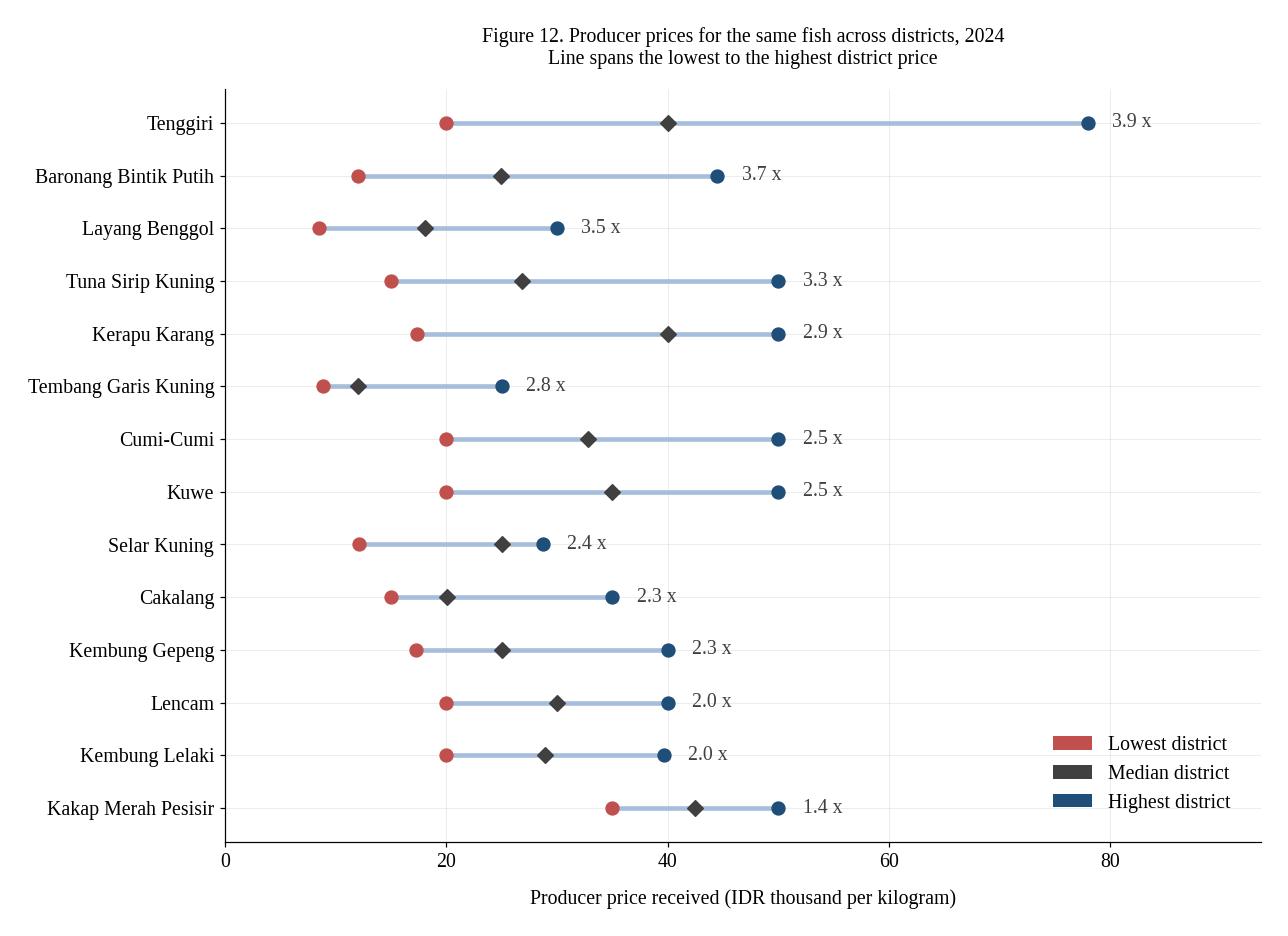

In [9]:
urut = DISPERSI.sort_values("Ratio")
posisi = np.arange(len(urut))

fig, sb = plt.subplots(figsize=(11.6, 8.4))
for i, (_, r) in enumerate(urut.iterrows()):
    sb.plot([r.Min_IDR / 1000, r.Max_IDR / 1000], [i, i], lw=3.0,
            color=WARNA["muda"], solid_capstyle="round", zorder=2)
    sb.scatter([r.Min_IDR / 1000], [i], s=70, color=WARNA["koordinasi"], zorder=3)
    sb.scatter([r.Max_IDR / 1000], [i], s=70, color=WARNA["struktural"], zorder=3)
    sb.scatter([r.Median_IDR / 1000], [i], s=52, marker="D", color=WARNA["netral"],
               zorder=4)
    sb.text(r.Max_IDR / 1000 + 2.2, i, "%.1f x" % r.Ratio, va="center", fontsize=13,
            color=WARNA["netral"])

sb.set_yticks(posisi)
sb.set_yticklabels([s.title() for s in urut.Species])
sb.set_xlabel("Producer price received (IDR thousand per kilogram)", labelpad=11)
sb.set_title("Figure 12. Producer prices for the same fish across districts, %d\n"
             "Line spans the lowest to the highest district price" % TAHUN_PRODUKSI,
             pad=16)
sb.set_xlim(0, urut.Max_IDR.max() / 1000 * 1.20)

penanda = [matplotlib.patches.Patch(facecolor=WARNA["koordinasi"], label="Lowest district"),
           matplotlib.patches.Patch(facecolor=WARNA["netral"], label="Median district"),
           matplotlib.patches.Patch(facecolor=WARNA["struktural"], label="Highest district")]
sb.legend(handles=penanda, loc="lower right", borderaxespad=1.1)
plt.tight_layout()
fig.savefig(os.path.join(JALUR["03_gambar"], "figure12_producer_price_range.png"))
plt.show()

## Langkah 3. Ketidaksesuaian ruang dengan data terbaru

Sebaran produksi menurut kabupaten dihitung ulang memakai data 2024, lalu dibandingkan
dengan sebaran penduduk sebagai pendekatan sebaran kebutuhan. Hasilnya dibandingkan pula
dengan hasil yang memakai data 2018 agar diketahui seberapa jauh kesimpulan bergantung pada
umur data.


In [10]:
GUGUS = {"Buton": "island", "Muna": "island", "Wakatobi": "island",
         "Buton Utara": "island", "Konawe Kepulauan": "island", "Muna Barat": "island",
         "Buton Tengah": "island", "Buton Selatan": "island", "Baubau": "island",
         "Konawe": "mainland", "Kolaka": "mainland", "Konawe Selatan": "mainland",
         "Bombana": "mainland", "Kolaka Utara": "mainland", "Konawe Utara": "mainland",
         "Kolaka Timur": "mainland", "Kendari": "mainland"}

penduduk = SEB["penduduk"].set_index("wilayah")["penduduk"]
p18 = SEB["perikanan18"]
tahun_lama = int(p18.dropna(subset=["produksi_ton"]).tahun.max())
lama = p18[p18.tahun == tahun_lama].set_index("wilayah")["produksi_ton"]
baru = KKP.groupby("wilayah").ton.sum()

RUANG = pd.DataFrame({"Population": penduduk})
RUANG["Catch %d" % tahun_lama] = lama.reindex(RUANG.index).fillna(0.0)
RUANG["Catch %d" % TAHUN_PRODUKSI] = baru.reindex(RUANG.index).fillna(0.0)
RUANG["Demand share"] = RUANG.Population / RUANG.Population.sum()
for t in [tahun_lama, TAHUN_PRODUKSI]:
    k = "Catch %d" % t
    RUANG["Supply share %d" % t] = RUANG[k] / RUANG[k].sum()
    RUANG["Mismatch %d" % t] = RUANG["Supply share %d" % t] - RUANG["Demand share"]
RUANG["Cluster"] = [GUGUS.get(w, "mainland") for w in RUANG.index]
RUANG.index.name = "District"

IKS = {t: float(RUANG["Mismatch %d" % t].abs().sum() / 2)
       for t in [tahun_lama, TAHUN_PRODUKSI]}
rho = RUANG["Supply share %d" % tahun_lama].corr(
    RUANG["Supply share %d" % TAHUN_PRODUKSI], method="spearman")

print(RUANG[["Catch %d" % tahun_lama, "Catch %d" % TAHUN_PRODUKSI, "Demand share",
             "Mismatch %d" % tahun_lama, "Mismatch %d" % TAHUN_PRODUKSI, "Cluster"]]
      .sort_values("Mismatch %d" % TAHUN_PRODUKSI, ascending=False).round(4).to_string())
RUANG.round(4).to_csv(os.path.join(JALUR["02_tabel"], "table23_spatial_mismatch.csv"))

print()
print("Indeks ketidaksesuaian ruang %d: %.4f" % (tahun_lama, IKS[tahun_lama]))
print("Indeks ketidaksesuaian ruang %d: %.4f" % (TAHUN_PRODUKSI, IKS[TAHUN_PRODUKSI]))
print("Korelasi peringkat pangsa produksi antarkedua tahun: %.3f" % rho)
print()

kol = "Mismatch %d" % TAHUN_PRODUKSI
pulau, darat = RUANG[RUANG.Cluster == "island"][kol], RUANG[RUANG.Cluster == "mainland"][kol]
print("Pola menurut gugus geografis pada data %d:" % TAHUN_PRODUKSI)
print("  Kepulauan : %d dari %d wilayah surplus, rata rata %+.4f"
      % ((pulau > 0).sum(), len(pulau), pulau.mean()))
print("  Daratan   : %d dari %d wilayah surplus, rata rata %+.4f"
      % ((darat > 0).sum(), len(darat), darat.mean()))
uji_gugus = stats.mannwhitneyu(pulau, darat, alternative="greater")
print("  Uji Mann Whitney arah kepulauan lebih tinggi: p = %.4f" % uji_gugus.pvalue)
if uji_gugus.pvalue < 0.05:
    print("  Perbedaan antargugus nyata, sehingga ketidaksesuaian ruang berakar pada "
          "geografi dan menuntut penanganan pada pengangkutan.")
else:
    print("  Perbedaan antargugus belum nyata secara statistik pada sampel sekecil ini.")

                  Catch 2018  Catch 2024  Demand share  Mismatch 2018  Mismatch 2024   Cluster
District                                                                                      
Buton Selatan       36654.74    24188.57        0.0362         0.1431         0.0525    island
Buton Tengah        17393.17    25854.71        0.0434         0.0417         0.0515    island
Bombana              4883.93    29516.01        0.0575        -0.0336         0.0508  mainland
Wakatobi             1168.37    22797.14        0.0423        -0.0366         0.0414    island
Konawe Utara        14765.56    15462.95        0.0267         0.0455         0.0300  mainland
Buton               26155.04    19333.42        0.0436         0.0844         0.0273    island
Konawe Kepulauan     5746.46    10036.56        0.0142         0.0139         0.0226    island
Muna Barat           9547.32    14397.96        0.0327         0.0140         0.0201    island
Baubau              13432.06    18705.51        0.

## Langkah 4. Menghitung ulang alokasi dan menguji ketahanannya

Model pemrograman linear tahap pertama dijalankan ulang dengan kapasitas dari kedua sumber
data. Bentuk model, tarif friksi, dan struktur biaya perpindahan tidak diubah sedikit pun,
sehingga perbedaan hasil sepenuhnya berasal dari data.

Satu perbaikan ditambahkan pada pelaporan. Selain pangsa kebutuhan yang dapat dipenuhi dari
dalam provinsi, dihitung pula berapa banyak pasokan yang harus melintasi batas kabupaten.
Besaran terakhir inilah yang menentukan beban penjadwalan pengangkutan, dan karena itu
merupakan keluaran yang paling berguna bagi penyusun kebijakan.


In [11]:
from scipy.optimize import linprog

hari = (P["hari_layanan_min"] + P["hari_layanan_maks"]) / 2
KEBUTUHAN = (P["penerima_sultra"] * hari * P["frekuensi_menu_ikan"]
             * P["gram_ikan_per_porsi"] / 1000.0 / 1000.0)

# Harga produsen kini dapat diambil langsung dari data KKP, tidak lagi dari satu
# komoditas tunggal. Dipakai harga tertimbang volume seluruh tangkapan laut.
HARGA_KKP = float(np.average(LAUT.harga_kg, weights=LAUT.ton))
tongkol = SEB["tongkol"]
HARGA_PANEL = float(tongkol[tongkol.level_harga == "produsen"].harga_rp_kg.mean())
print("Harga produsen tertimbang seluruh tangkapan laut (KKP %d): Rp%s per kilogram"
      % (TAHUN_PRODUKSI, format(HARGA_KKP, ",.0f")))
print("Harga produsen ikan tongkol (Panel Harga 2022 sampai 2024)  : Rp%s per kilogram"
      % format(HARGA_PANEL, ",.0f"))
print("Selisih antarsumber: %.1f persen"
      % ((HARGA_KKP / HARGA_PANEL - 1) * 100))
print("Dipakai harga KKP karena sezaman dengan data produksi dan mencakup seluruh jenis.")
HARGA_LOKAL = HARGA_KKP

bf = SEB["biaya_friksi"].set_index("Commodity")
FRIKSI_PCT = float(bf.loc[bf["Permanent share"] >= 0.5,
                          "Structural friction (% of price)"].mean())
TARIF = HARGA_LOKAL * FRIKSI_PCT / 100.0
PREMI_LUAR, LIPAT_GUGUS, LIPAT_LUAR = 0.15, 2.0, 3.0

wil = list(RUANG.index); n = len(wil); gugus = RUANG.Cluster.to_dict()
permintaan = (RUANG["Demand share"] * KEBUTUHAN).values.astype(float)

def alokasi(kapasitas, phi):
    biaya = []
    for j in wil:
        for k in wil:
            tambah = 0.0 if j == k else TARIF * (1.0 if gugus[j] == gugus[k]
                                                 else LIPAT_GUGUS)
            biaya.append((HARGA_LOKAL + tambah) * 1000.0)
    biaya += [(HARGA_LOKAL * (1 + PREMI_LUAR) + TARIF * LIPAT_LUAR) * 1000.0] * n
    Aeq = np.zeros((n, n * n + n))
    for k in range(n):
        for j in range(n):
            Aeq[k, j * n + k] = 1.0
        Aeq[k, n * n + k] = 1.0
    Aub = np.zeros((n, n * n + n))
    for j in range(n):
        for k in range(n):
            Aub[j, j * n + k] = 1.0
    r = linprog(np.array(biaya, float), A_ub=Aub, b_ub=kapasitas.values * phi,
                A_eq=Aeq, b_eq=permintaan, bounds=[(0, None)] * (n * n + n),
                method="highs")
    if not r.success:
        return None
    X = r.x[:n * n].reshape(n, n); Z = r.x[n * n:]
    lokal, luar = X.sum(), Z.sum()
    antar = lokal - np.trace(X)
    return dict(phi=phi, ton_lokal=lokal, ton_luar=luar,
                pangsa_lokal=lokal / (lokal + luar) if (lokal + luar) else np.nan,
                ton_antar=antar, pangsa_antar=antar / lokal if lokal else np.nan,
                nilai=lokal * HARGA_LOKAL * 1000.0, biaya=r.fun, X=X)

print()
print("Kebutuhan ikan program: %s ton per tahun" % format(KEBUTUHAN, ",.0f"))

HASIL = {}
for t in [tahun_lama, TAHUN_PRODUKSI]:
    kap = RUANG["Catch %d" % t]
    baris = [{k: v for k, v in alokasi(kap, phi).items() if k != "X"}
             for phi in [0.005, 0.010, 0.015, 0.020, 0.025, 0.030, 0.050]
             if alokasi(kap, phi)]
    tab = pd.DataFrame(baris)
    jenuh = tab[tab.pangsa_lokal >= 0.999]
    phi_j = float(jenuh.phi.min()) if len(jenuh) else np.nan
    HASIL[t] = dict(tabel=tab, rasio=KEBUTUHAN / kap.sum(), phi_jenuh=phi_j,
                    dasar=alokasi(kap, phi_j) if not np.isnan(phi_j) else None)
    print("  Data %d: produksi %s ton, kebutuhan %.2f persen, titik jenuh %.1f persen"
          % (t, format(kap.sum(), ",.0f"), KEBUTUHAN / kap.sum() * 100, phi_j * 100))

TAB = HASIL[TAHUN_PRODUKSI]["tabel"].rename(columns={
    "phi": "Absorption cap", "ton_lokal": "Local sourcing (t)",
    "ton_luar": "Outside sourcing (t)", "pangsa_lokal": "Local share",
    "ton_antar": "Inter-district flow (t)", "pangsa_antar": "Inter-district share",
    "nilai": "Value to producers (IDR)", "biaya": "Total cost (IDR)"})
print()
print(TAB.round(3).to_string(index=False))
TAB.round(3).to_csv(os.path.join(JALUR["02_tabel"],
                    "table24_allocation_final.csv"), index=False)

DASAR = HASIL[TAHUN_PRODUKSI]["dasar"]
print()
print("Skenario dasar pada titik jenuh %.1f persen:"
      % (HASIL[TAHUN_PRODUKSI]["phi_jenuh"] * 100))
print("  Kebutuhan dipenuhi dari dalam provinsi : %.1f persen"
      % (DASAR["pangsa_lokal"] * 100))
print("  Pasokan yang melintasi batas kabupaten : %s ton (%.1f persen pasokan lokal)"
      % (format(DASAR["ton_antar"], ",.0f"), DASAR["pangsa_antar"] * 100))
print("  Nilai yang sampai ke produsen          : Rp%s"
      % format(DASAR["nilai"], ",.0f"))

Harga produsen tertimbang seluruh tangkapan laut (KKP 2024): Rp26,239 per kilogram
Harga produsen ikan tongkol (Panel Harga 2022 sampai 2024)  : Rp21,095 per kilogram
Selisih antarsumber: 24.4 persen
Dipakai harga KKP karena sezaman dengan data produksi dan mencakup seluruh jenis.

Kebutuhan ikan program: 5,196 ton per tahun
  Data 2018: produksi 204,365 ton, kebutuhan 2.54 persen, titik jenuh 3.0 persen
  Data 2024: produksi 272,457 ton, kebutuhan 1.91 persen, titik jenuh 2.0 persen

 Absorption cap  Local sourcing (t)  Outside sourcing (t)  Local share  Inter-district flow (t)  Inter-district share  Value to producers (IDR)  Total cost (IDR)
          0.005            1362.283              3833.724        0.262                    0.000                 0.000              3.574527e+10      1.674077e+11
          0.010            2724.566              2471.441        0.524                  137.048                 0.050              7.149054e+10      1.565582e+11
          0.015         

### Gambar tiga belas, ketahanan hasil terhadap pilihan sumber data

Grafik kiri menampilkan pangsa kebutuhan yang dapat dipenuhi dari dalam provinsi pada
berbagai batas serapan, dihitung dengan kedua sumber data. Grafik kanan menampilkan
ketidaksesuaian ruang menurut kabupaten pada kedua sumber. Kesamaan bentuk pada grafik kiri
menunjukkan kesimpulan yang tidak bergantung pada sumber, sedangkan perbedaan pada grafik
kanan menunjukkan wilayah mana yang pencatatannya paling banyak berubah.


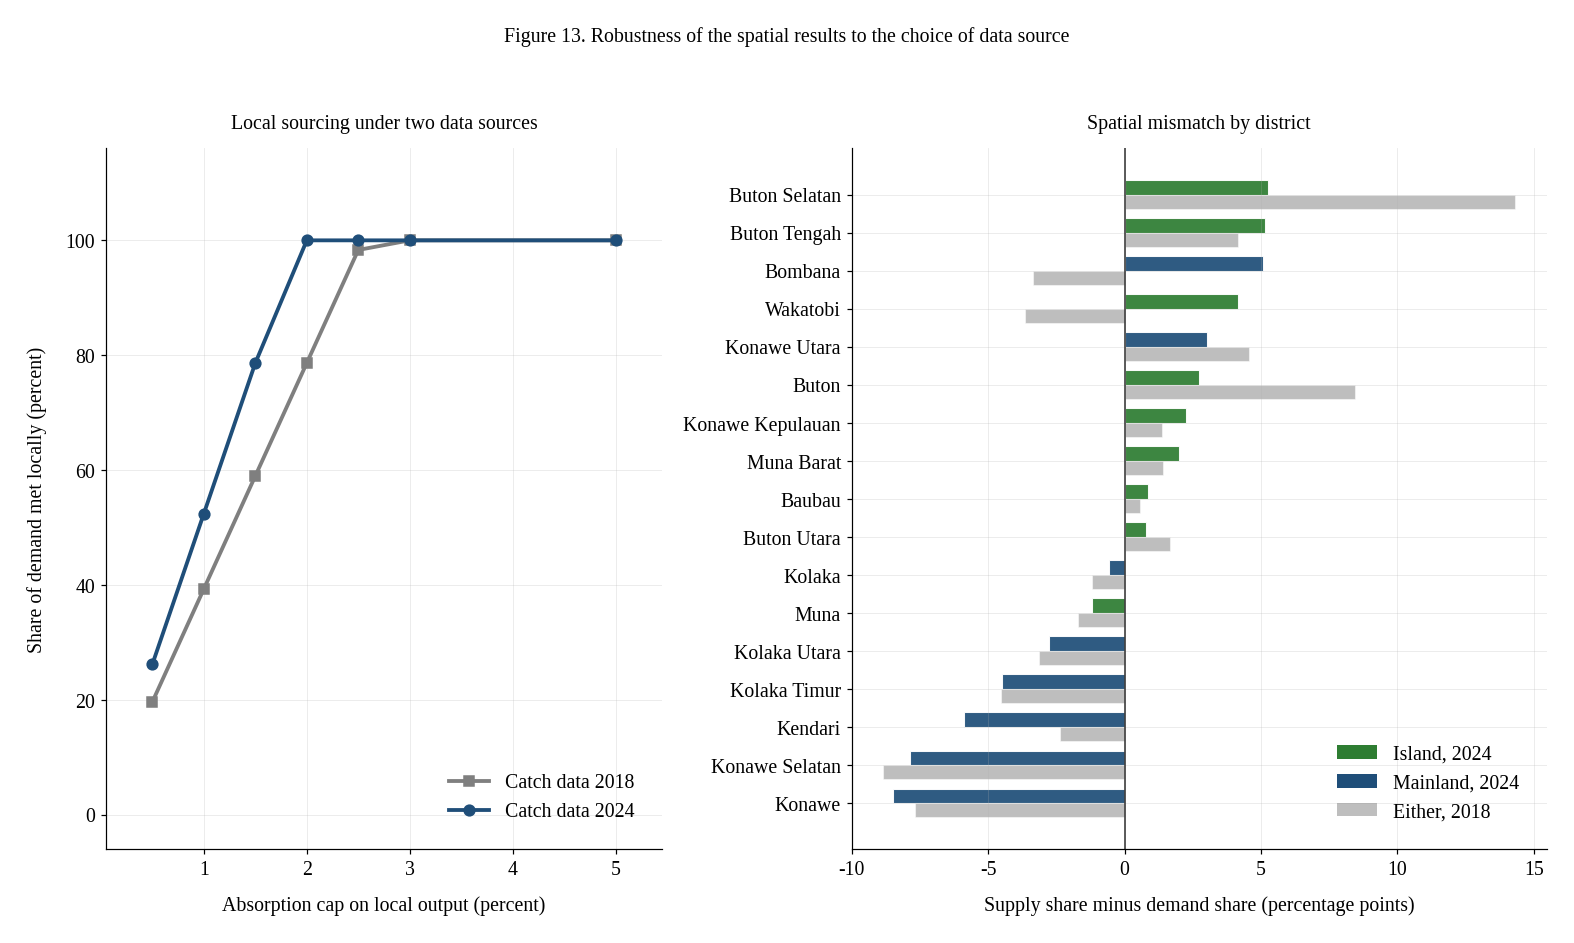

In [12]:
fig, (kiri, kanan) = plt.subplots(1, 2, figsize=(14.2, 8.4),
                                  gridspec_kw={"width_ratios": [1, 1.25]})

for t, w, tanda in [(tahun_lama, WARNA["campuran"], "s"),
                    (TAHUN_PRODUKSI, WARNA["struktural"], "o")]:
    tb = HASIL[t]["tabel"]
    kiri.plot(tb.phi * 100, tb.pangsa_lokal * 100, marker=tanda, ms=7, lw=2.5,
              color=w, label="Catch data %d" % t)
kiri.set_xlabel("Absorption cap on local output (percent)", labelpad=11)
kiri.set_ylabel("Share of demand met locally (percent)", labelpad=12)
kiri.set_title("Local sourcing under two data sources", pad=13)
kiri.set_ylim(-6, 116); kiri.margins(x=0.10)
kiri.legend(loc="lower right", borderaxespad=1.0)

urut = RUANG.sort_values("Mismatch %d" % TAHUN_PRODUKSI)
posisi = np.arange(len(urut)); tinggi = 0.38
kanan.barh(posisi + tinggi / 2, urut["Mismatch %d" % TAHUN_PRODUKSI] * 100, tinggi,
           color=[WARNA["aksen"] if c == "island" else WARNA["struktural"]
                  for c in urut.Cluster], alpha=0.93, edgecolor="white", linewidth=0.7)
kanan.barh(posisi - tinggi / 2, urut["Mismatch %d" % tahun_lama] * 100, tinggi,
           color=WARNA["campuran"], alpha=0.5, edgecolor="white", linewidth=0.7)
kanan.set_yticks(posisi); kanan.set_yticklabels(urut.index, fontsize=13)
kanan.axvline(0, color=WARNA["netral"], lw=1.1)
kanan.set_xlabel("Supply share minus demand share (percentage points)", labelpad=11)
kanan.set_title("Spatial mismatch by district", pad=13)
penanda = [matplotlib.patches.Patch(facecolor=WARNA["aksen"],
                                    label="Island, %d" % TAHUN_PRODUKSI),
           matplotlib.patches.Patch(facecolor=WARNA["struktural"],
                                    label="Mainland, %d" % TAHUN_PRODUKSI),
           matplotlib.patches.Patch(facecolor=WARNA["campuran"], alpha=0.5,
                                    label="Either, %d" % tahun_lama)]
kanan.legend(handles=penanda, loc="lower right", borderaxespad=1.0)

fig.suptitle("Figure 13. Robustness of the spatial results to the choice of data source",
             y=0.985)
plt.tight_layout(rect=[0, 0, 1, 0.958])
fig.savefig(os.path.join(JALUR["03_gambar"], "figure13_source_robustness.png"))
plt.show()

## Langkah 5. Lembar angka final untuk naskah

Sel berikut mengumpulkan seluruh angka yang layak dibawa ke naskah, lengkap dengan sumber
dan tahapan yang menghasilkannya. Angka yang tidak lolos pengujian tidak dimasukkan, dan
angka yang gugur pada tahap sebelumnya dicatat secara terpisah agar tidak terpakai kembali
karena kelalaian.


In [13]:
ANGGARAN_MIN = P["penerima_sultra"] * P["bahan_baku_kecil"] * hari
ANGGARAN_MAK = P["penerima_sultra"] * P["bahan_baku_besar"] * hari
NILAI_IKAN_PORSI = (P["gram_ikan_per_porsi"] / 1000.0) * HARGA_LOKAL
PANGSA_IKAN = (P["frekuensi_menu_ikan"] * NILAI_IKAN_PORSI) / P["bahan_baku_kecil"]

FINAL = [
 dict(Kelompok="Program", Butir="Penerima manfaat Sulawesi Tenggara",
      Nilai="%s orang" % format(int(P["penerima_sultra"]), ","),
      Sumber="Kanwil DJPb Sultra, 31 Juli 2026", Tahap="Dua"),
 dict(Kelompok="Program", Butir="Dapur yang beroperasi",
      Nilai="%d unit di 17 kabupaten kota" % P["sppg_sultra"],
      Sumber="Kanwil DJPb Sultra, 31 Juli 2026", Tahap="Dua"),
 dict(Kelompok="Program", Butir="Pemasok terdaftar",
      Nilai="%s pemasok" % format(int(P["pemasok_sultra"]), ","),
      Sumber="Kanwil DJPb Sultra, 31 Juli 2026", Tahap="Dua"),
 dict(Kelompok="Program", Butir="Rasio pemasok terhadap dapur",
      Nilai="%.2f, ambang penghentian sementara %d"
            % (P["pemasok_sultra"] / P["sppg_sultra"], P["pemasok_minimum"]),
      Sumber="Turunan dari data DJPb dan ketentuan BGN", Tahap="Dua"),
 dict(Kelompok="Program", Butir="Anggaran bahan baku setahun",
      Nilai="Rp%.3f sampai %.3f triliun" % (ANGGARAN_MIN / 1e12, ANGGARAN_MAK / 1e12),
      Sumber="Turunan dari Juknis BGN 401.1 dan data DJPb", Tahap="Dua"),

 dict(Kelompok="Friksi eceran", Butir="Komoditas friksi struktural",
      Nilai="Gula pasir, beras, daging sapi, minyak goreng",
      Sumber="Model komponen tak teramati pada harga eceran", Tahap="Satu"),
 dict(Kelompok="Friksi eceran", Butir="Komoditas kegagalan koordinasi",
      Nilai="Cabai rawit, cabai merah, bawang merah, telur, daging ayam",
      Sumber="Model komponen tak teramati pada harga eceran", Tahap="Satu"),
 dict(Kelompok="Friksi eceran", Butir="Biaya friksi struktural",
      Nilai="%.2f persen harga eceran, setara Rp%s per kilogram"
            % (FRIKSI_PCT, format(TARIF, ",.0f")),
      Sumber="Lapis pertama", Tahap="Satu"),
 dict(Kelompok="Friksi eceran", Butir="Indeks konektivitas total",
      Nilai="%.2f persen" % CT2.get("hasil_tahap2", {}).get(
          "indeks_konektivitas_total_persen",
          json.load(open(berkas("catatan_teknis.json"), encoding="utf-8")
                    )["hasil_utama"]["indeks_konektivitas_total_persen"]),
      Sumber="Vektor autoregresi dengan penyusutan", Tahap="Satu"),

 dict(Kelompok="Friksi produsen", Butir="Sebaran harga produsen antarkabupaten",
      Nilai="simpangan baku logaritma %.3f, rasio tertinggi terhadap terendah %.2f kali"
            % (SD_PRODUSEN, RASIO_PRODUSEN),
      Sumber="Portal data KKP %d, %d jenis ikan" % (TAHUN_PRODUKSI, len(DISPERSI)),
      Tahap="Tiga"),
 dict(Kelompok="Friksi produsen", Butir="Perbandingan terhadap sebaran eceran",
      Nilai="%.1f kali lebih lebar di tingkat produsen" % LIPAT,
      Sumber="Perbandingan lapis pertama dan data KKP", Tahap="Tiga"),
 dict(Kelompok="Friksi produsen", Butir="Uji pembulatan pelaporan",
      Nilai="sebaran teramati %.1f kali melampaui simulasi, p kurang dari 0,001"
            % UJI.Ratio.min(),
      Sumber="Simulasi tiga ribu ulangan", Tahap="Tiga"),
 dict(Kelompok="Friksi produsen", Butir="Penjelasan kekuatan tawar pembeli",
      Nilai="%s, elastisitas %+.4f (p %.4f), menjelaskan %.1f persen ragam"
            % (VONIS_TAWAR, ELASTISITAS, P_TAWAR, R2_DALAM * 100),
      Sumber="Regresi dengan efek tetap jenis ikan", Tahap="Tiga"),

 dict(Kelompok="Produksi", Butir="Produksi perikanan tangkap %d" % TAHUN_PRODUKSI,
      Nilai="%s ton, nilai Rp%.3f triliun"
            % (format(KKP.ton.sum(), ",.0f"), NILAI_PRODUKSI / 1e12),
      Sumber="Portal data KKP", Tahap="Tiga"),
 dict(Kelompok="Produksi", Butir="Pemeriksaan silang antarsumber",
      Nilai="selisih %.2f persen terhadap portal Satu Data provinsi" % SELISIH_SUMBER,
      Sumber="KKP dan Dinas Kelautan dan Perikanan Sultra", Tahap="Tiga"),
 dict(Kelompok="Produksi", Butir="Harga produsen tertimbang",
      Nilai="Rp%s per kilogram" % format(HARGA_LOKAL, ",.0f"),
      Sumber="Portal data KKP %d" % TAHUN_PRODUKSI, Tahap="Tiga"),

 dict(Kelompok="Pencocokan", Butir="Kebutuhan ikan program",
      Nilai="%s ton setara %.2f persen produksi provinsi"
            % (format(KEBUTUHAN, ",.0f"), HASIL[TAHUN_PRODUKSI]["rasio"] * 100),
      Sumber="Turunan dari standar gizi dan data produksi", Tahap="Tiga"),
 dict(Kelompok="Pencocokan", Butir="Kepekaan terhadap asumsi menu",
      Nilai="paling tinggi %.2f persen produksi pada seluruh kisi"
            % CT2.get("hasil_tahap2", {}).get("kepekaan_maksimum_persen", float("nan")),
      Sumber="Kisi kepekaan tahap kedua", Tahap="Dua"),
 dict(Kelompok="Pencocokan", Butir="Pangsa ikan dalam anggaran bahan baku",
      Nilai="%.1f persen, diturunkan bukan diasumsikan" % (PANGSA_IKAN * 100),
      Sumber="Turunan dari standar gizi, harga, dan frekuensi menu", Tahap="Tiga"),
 dict(Kelompok="Pencocokan", Butir="Indeks ketidaksesuaian ruang",
      Nilai="%.4f pada data %d" % (IKS[TAHUN_PRODUKSI], TAHUN_PRODUKSI),
      Sumber="Selisih pangsa produksi dan pangsa penduduk", Tahap="Tiga"),
 dict(Kelompok="Pencocokan", Butir="Pola gugus geografis",
      Nilai="%d dari %d wilayah kepulauan surplus, %d dari %d wilayah daratan surplus"
            % ((pulau > 0).sum(), len(pulau), (darat > 0).sum(), len(darat)),
      Sumber="Data KKP %d" % TAHUN_PRODUKSI, Tahap="Tiga"),
 dict(Kelompok="Pencocokan", Butir="Pasokan yang melintasi batas kabupaten",
      Nilai="%s ton setara %.1f persen pasokan lokal"
            % (format(DASAR["ton_antar"], ",.0f"), DASAR["pangsa_antar"] * 100),
      Sumber="Pemrograman linear pada titik jenuh", Tahap="Tiga"),
 dict(Kelompok="Pencocokan", Butir="Nilai yang sampai ke produsen",
      Nilai="Rp%.3f triliun" % (DASAR["nilai"] / 1e12),
      Sumber="Pemrograman linear pada titik jenuh", Tahap="Tiga"),
]

LEMBAR = pd.DataFrame(FINAL)
for kel, sub in LEMBAR.groupby("Kelompok", sort=False):
    print("=" * 78)
    print(kel.upper())
    print("=" * 78)
    for _, r in sub.iterrows():
        print("  %-42s %s" % (r.Butir, r.Nilai))
        print("  %-42s (%s, tahap %s)" % ("", r.Sumber, r.Tahap))
    print()
LEMBAR.to_csv(os.path.join(JALUR["04_final"], "lembar_angka_final.csv"), index=False)

PROGRAM
  Penerima manfaat Sulawesi Tenggara         704,066 orang
                                             (Kanwil DJPb Sultra, 31 Juli 2026, tahap Dua)
  Dapur yang beroperasi                      282 unit di 17 kabupaten kota
                                             (Kanwil DJPb Sultra, 31 Juli 2026, tahap Dua)
  Pemasok terdaftar                          1,969 pemasok
                                             (Kanwil DJPb Sultra, 31 Juli 2026, tahap Dua)
  Rasio pemasok terhadap dapur               6.98, ambang penghentian sementara 15
                                             (Turunan dari data DJPb dan ketentuan BGN, tahap Dua)
  Anggaran bahan baku setahun                Rp1.386 sampai 1.732 triliun
                                             (Turunan dari Juknis BGN 401.1 dan data DJPb, tahap Dua)

FRIKSI ECERAN
  Komoditas friksi struktural                Gula pasir, beras, daging sapi, minyak goreng
                                             (Model komponen t

In [14]:
GUGUR = [
 dict(Butir="Kendari sebagai kota pusat penyalur guncangan harga",
      Alasan="Rasio dominasi hanya 1,048 sehingga arus antarkota hampir setara",
      Tahap="Satu"),
 dict(Butir="Marjin rantai pasok sebesar 47,3 persen",
      Alasan="Diturunkan dari dua asumsi yang saling bertentangan, yaitu pangsa ikan "
             "dua puluh lima persen yang mensyaratkan menu ikan pada 95 persen hari "
             "layanan",
      Tahap="Dua"),
 dict(Butir="Berat ikan lima puluh gram per porsi",
      Alasan="Standar protein hewani menuntut 81 sampai 108 gram ikan utuh",
      Tahap="Dua"),
 dict(Butir="Data produksi perikanan tahun 2018 sebagai acuan",
      Alasan="Korelasi peringkat terhadap data 2024 hanya %.3f dan banyak sel kosong, "
             "termasuk kabupaten kepulauan yang tercatat tidak wajar rendah" % rho,
      Tahap="Tiga"),
 dict(Butir="Kekuatan tawar pembeli sebagai penjelas utama sebaran harga produsen",
      Alasan="Hubungan nyata tetapi hanya menjelaskan %.1f persen ragam harga di dalam "
             "jenis ikan yang sama, sehingga tidak dapat disebut sebab utama"
             % (R2_DALAM * 100),
      Tahap="Tiga"),
]
DAFTAR_GUGUR = pd.DataFrame(GUGUR)
print("KLAIM YANG TIDAK BOLEH DIPAKAI DALAM NASKAH")
print("=" * 78)
for _, r in DAFTAR_GUGUR.iterrows():
    print("  %s" % r.Butir)
    print("    Alasan: %s (gugur pada tahap %s)" % (r.Alasan, r.Tahap))
    print()
DAFTAR_GUGUR.to_csv(os.path.join(JALUR["04_final"], "klaim_gugur.csv"), index=False)

KLAIM YANG TIDAK BOLEH DIPAKAI DALAM NASKAH
  Kendari sebagai kota pusat penyalur guncangan harga
    Alasan: Rasio dominasi hanya 1,048 sehingga arus antarkota hampir setara (gugur pada tahap Satu)

  Marjin rantai pasok sebesar 47,3 persen
    Alasan: Diturunkan dari dua asumsi yang saling bertentangan, yaitu pangsa ikan dua puluh lima persen yang mensyaratkan menu ikan pada 95 persen hari layanan (gugur pada tahap Dua)

  Berat ikan lima puluh gram per porsi
    Alasan: Standar protein hewani menuntut 81 sampai 108 gram ikan utuh (gugur pada tahap Dua)

  Data produksi perikanan tahun 2018 sebagai acuan
    Alasan: Korelasi peringkat terhadap data 2024 hanya 0.542 dan banyak sel kosong, termasuk kabupaten kepulauan yang tercatat tidak wajar rendah (gugur pada tahap Tiga)

  Kekuatan tawar pembeli sebagai penjelas utama sebaran harga produsen
    Alasan: Hubungan nyata tetapi hanya menjelaskan 4.1 persen ragam harga di dalam jenis ikan yang sama, sehingga tidak dapat disebut sebab ut

## Langkah 6. Menyimpan dan mengunduh arsip tahap ketiga

In [15]:
CATATAN3 = {
    "waktu_pengolahan": dt.datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
    "sumber_produksi": {
        "kkp_berkas": os.path.basename(BERKAS_KKP),
        "kkp_keterangan": KET_KKP,
        "portal_provinsi": ASAL_DKP,
        "alamat_portal": HALAMAN.format(kode=KODE_TABEL, tahun=TAHUN_PRODUKSI),
        "pemutakhiran_portal": PEMUTAKHIRAN,
        "selisih_antarsumber_persen": round(float(SELISIH_SUMBER), 2),
    },
    "hasil_tahap3": {
        "tahun_produksi": TAHUN_PRODUKSI,
        "produksi_total_ton": round(float(KKP.ton.sum()), 1),
        "nilai_produksi_rp": round(float(NILAI_PRODUKSI), 0),
        "harga_produsen_tertimbang_rp_kg": round(float(HARGA_LOKAL), 0),
        "sd_log_harga_produsen": round(float(SD_PRODUSEN), 4),
        "rasio_harga_produsen": round(float(RASIO_PRODUSEN), 2),
        "sd_log_harga_eceran": round(float(SD_ECERAN), 4),
        "lipat_produsen_terhadap_eceran": round(float(LIPAT), 2),
        "uji_pembulatan_p": float(UJI.p_value.max()),
        "uji_pembulatan_lipat": round(float(UJI.Ratio.min()), 1),
        "uji_kekuatan_tawar_elastisitas": round(float(ELASTISITAS), 4),
        "uji_kekuatan_tawar_p": round(float(P_TAWAR), 4),
        "uji_kekuatan_tawar_r2_dalam": round(float(R2_DALAM), 4),
        "indeks_ketidaksesuaian": round(float(IKS[TAHUN_PRODUKSI]), 4),
        "korelasi_peringkat_antartahun": round(float(rho), 3),
        "kebutuhan_ikan_ton": round(float(KEBUTUHAN), 1),
        "kebutuhan_terhadap_produksi_persen": round(
            float(HASIL[TAHUN_PRODUKSI]["rasio"] * 100), 2),
        "titik_jenuh_serapan": round(float(HASIL[TAHUN_PRODUKSI]["phi_jenuh"]), 3),
        "pasokan_antarkabupaten_ton": round(float(DASAR["ton_antar"]), 1),
        "pasokan_antarkabupaten_persen": round(float(DASAR["pangsa_antar"] * 100), 1),
        "nilai_ke_produsen_rp": round(float(DASAR["nilai"]), 0),
        "pangsa_ikan_anggaran_persen": round(float(PANGSA_IKAN * 100), 2),
    },
    "batasan_tersisa": [
        "Harga rata rata tertimbang pada berkas KKP banyak yang bulat, sehingga harga "
        "per pengamatan tidak presisi meskipun sebarannya sudah diuji nyata.",
        "Perbedaan mutu dan ukuran ikan antarkabupaten tidak dapat dikendalikan dengan "
        "data yang tersedia, sehingga sebagian sebaran harga mungkin mencerminkan mutu.",
        "Sebaran eceran berasal dari dua kota sedangkan sebaran produsen dari belasan "
        "kabupaten, sehingga perbandingan keduanya belum sepenuhnya setara.",
        "Frekuensi kemunculan menu ikan tetap merupakan pilihan kebijakan yang diuji "
        "melalui kisi kepekaan, bukan angka yang ditetapkan.",
    ],
}
with open(os.path.join(JALUR["04_final"], "catatan_teknis_tahap3.json"), "w",
          encoding="utf-8") as f:
    json.dump(CATATAN3, f, indent=2, ensure_ascii=False)
print(json.dumps(CATATAN3["hasil_tahap3"], indent=2, ensure_ascii=False))

{
  "tahun_produksi": 2024,
  "produksi_total_ton": 272456.7,
  "nilai_produksi_rp": 7155019000000.0,
  "harga_produsen_tertimbang_rp_kg": 26239.0,
  "sd_log_harga_produsen": 0.2977,
  "rasio_harga_produsen": 2.69,
  "sd_log_harga_eceran": 0.0989,
  "lipat_produsen_terhadap_eceran": 3.01,
  "uji_pembulatan_p": 0.0,
  "uji_pembulatan_lipat": 14.2,
  "uji_kekuatan_tawar_elastisitas": -0.0639,
  "uji_kekuatan_tawar_p": 0.013,
  "uji_kekuatan_tawar_r2_dalam": 0.0408,
  "indeks_ketidaksesuaian": 0.3125,
  "korelasi_peringkat_antartahun": 0.542,
  "kebutuhan_ikan_ton": 5196.0,
  "kebutuhan_terhadap_produksi_persen": 1.91,
  "titik_jenuh_serapan": 0.02,
  "pasokan_antarkabupaten_ton": 1546.5,
  "pasokan_antarkabupaten_persen": 29.8,
  "nilai_ke_produsen_rp": 136339250849.0,
  "pangsa_ikan_anggaran_persen": 9.84
}


In [16]:
PUSTAKA3 = [
 dict(sitasi="Kementerian Kelautan dan Perikanan. (2026). Produksi perikanan tangkap "
             "menurut provinsi, kabupaten, kelompok ikan, dan jenis ikan tahun %d "
             "[Kumpulan data]. Portal Data Kelautan dan Perikanan." % TAHUN_PRODUKSI,
      tautan="https://portaldata.kkp.go.id",
      pakai="Volume, nilai, dan harga rata rata tertimbang produksi perikanan tangkap"),
 dict(sitasi="Dinas Kelautan dan Perikanan Provinsi Sulawesi Tenggara. (2025). Jumlah "
             "produksi perikanan tangkap Provinsi Sulawesi Tenggara tahun %d "
             "[Kumpulan data]. Satu Data Provinsi Sulawesi Tenggara." % TAHUN_PRODUKSI,
      tautan=HALAMAN.format(kode=KODE_TABEL, tahun=TAHUN_PRODUKSI),
      pakai="Pemeriksaan silang produksi perikanan tangkap menurut kabupaten"),
]
teks = ["DAFTAR PUSTAKA TAMBAHAN TAHAP KETIGA", ""]
for i, p in enumerate(PUSTAKA3, 1):
    teks += ["%d. %s" % (i, p["sitasi"]), "   Tautan: %s" % p["tautan"],
             "   Dipakai untuk: %s" % p["pakai"], ""]
teks += ["CATATAN", "",
         "Kedua sumber disusun oleh lembaga yang berbeda dan diperiksa silang pada",
         "notebook ini dengan selisih total %.2f persen, sehingga keduanya dapat" % SELISIH_SUMBER,
         "dirujuk bersama sebagai penguat satu sama lain."]
PUSTAKA_TEKS = "\n".join(teks)
print(PUSTAKA_TEKS)
with open(os.path.join(JALUR["04_final"], "daftar_pustaka_tahap3.txt"), "w",
          encoding="utf-8") as f:
    f.write(PUSTAKA_TEKS)

DAFTAR PUSTAKA TAMBAHAN TAHAP KETIGA

1. Kementerian Kelautan dan Perikanan. (2026). Produksi perikanan tangkap menurut provinsi, kabupaten, kelompok ikan, dan jenis ikan tahun 2024 [Kumpulan data]. Portal Data Kelautan dan Perikanan.
   Tautan: https://portaldata.kkp.go.id
   Dipakai untuk: Volume, nilai, dan harga rata rata tertimbang produksi perikanan tangkap

2. Dinas Kelautan dan Perikanan Provinsi Sulawesi Tenggara. (2025). Jumlah produksi perikanan tangkap Provinsi Sulawesi Tenggara tahun 2024 [Kumpulan data]. Satu Data Provinsi Sulawesi Tenggara.
   Tautan: https://simdata.sultraprov.go.id/detail-tabel/tabel_74_356/2024
   Dipakai untuk: Pemeriksaan silang produksi perikanan tangkap menurut kabupaten

CATATAN

Kedua sumber disusun oleh lembaga yang berbeda dan diperiksa silang pada
notebook ini dengan selisih total 0.45 persen, sehingga keduanya dapat
dirujuk bersama sebagai penguat satu sama lain.


In [17]:
NAMA = "SIMPUL_Forkestra2026_tahap3_%s" % dt.datetime.now().strftime("%Y%m%d_%H%M")
tujuan = os.path.join("/content" if DI_COLAB else os.getcwd(), NAMA + ".zip")
jumlah = 0
with zipfile.ZipFile(tujuan, "w", zipfile.ZIP_DEFLATED) as z:
    for akar, _, berkas_ in os.walk(JALUR["akar"]):
        if "01_masukan" in akar:
            continue
        for nama in berkas_:
            if nama.lower().endswith(".zip"):
                continue
            penuh = os.path.join(akar, nama)
            z.write(penuh, os.path.relpath(penuh, JALUR["akar"]))
            jumlah += 1
print("Arsip tahap ketiga selesai.")
print("  Nama   :", os.path.basename(tujuan))
print("  Isi    : %d berkas" % jumlah)
print("  Ukuran : %.2f megabita" % (os.path.getsize(tujuan) / 1e6))
salinan = os.path.join(JALUR["akar"], os.path.basename(tujuan))
if os.path.abspath(salinan) != os.path.abspath(tujuan):
    shutil.copy2(tujuan, salinan)
if DI_COLAB:
    from google.colab import files
    files.download(tujuan)
    print("\nUnduhan dimulai secara otomatis.")
else:
    print("\nDi luar Colab, arsip tersedia pada:", tujuan)

Arsip tahap ketiga selesai.
  Nama   : SIMPUL_Forkestra2026_tahap3_20260923_0747.zip
  Isi    : 14 berkas
  Ukuran : 0.59 megabita


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


Unduhan dimulai secara otomatis.


### Penutup

Tahap ketiga menutup keterbatasan terakhir yang bersifat mendasar, yaitu umur data
produksi, dan sekaligus membuka temuan yang sebelumnya tidak terjangkau. Sebaran harga yang
dihadapi nelayan ternyata jauh lebih lebar daripada sebaran yang dihadapi konsumen. Temuan
itu memindahkan pusat persoalan dari hilir ke hulu, dan menjelaskan mengapa provinsi dengan
produksi perikanan besar tetap memiliki nelayan berpendapatan rendah.

Seluruh angka yang layak dibawa ke naskah sudah terkumpul pada lembar angka final.
